# Handwritten Digit Classification using Deep Learning

## Problem Statement

Handwritten digit recognition is a multi-class image classification problem.

Given a grayscale image of size 28×28 pixels representing a handwritten digit (0–9), the objective is to correctly predict which digit the image represents.

In this project, we aim to:

- Build and compare three neural network architectures:
  - A baseline Multi-Layer Perceptron (MLP)
  - A regularized MLP using Dropout
  - A Convolutional Neural Network (CNN)

- Evaluate model performance using:
  - Accuracy
  - Precision, Recall, and F1-score
  - Confusion Matrix

- Analyze generalization using separate train, validation (dev), and test sets.

The dataset used is the MNIST dataset, which contains 70,000 labeled handwritten digit images.

The goal is not only to achieve high accuracy, but also to understand:
- The impact of architecture choice
- The role of regularization
- Why CNNs are more suitable for image-based tasks

## Why This Problem Matters

Handwritten digit classification has real-world applications in:

- Postal code recognition
- Bank check processing
- Optical Character Recognition (OCR)
- Automated form reading systems

Although MNIST is a benchmark dataset, it provides a strong foundation for understanding modern image classification techniques and neural network behavior.

## Dataset Overview

The MNIST dataset consists of 70,000 grayscale images of handwritten digits (0–9).

- Image size: 28 × 28 pixels
- Number of classes: 10
- Pixel intensity range: 0–255
- Balanced dataset across classes

The dataset will be combined and later split into:
- Training set (75%)
- Validation set (12.5%)
- Test set (12.5%)

Before training, we perform:
- Data normalization (scaling pixel values to [0, 1])
- Reshaping depending on model architecture (MLP vs CNN)

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = tf.keras.datasets.mnist.load_data()

# Combine train and test for custom split
X_all = np.concatenate((X_train_raw, X_test_raw), axis=0)
y_all = np.concatenate((y_train_raw, y_test_raw), axis=0)

print("Total samples:", X_all.shape[0])
print("Image shape:", X_all.shape[1:])
print("Number of classes:", len(np.unique(y_all)))

Total samples: 70000
Image shape: (28, 28)
Number of classes: 10


## Sample Images

Below are randomly selected examples from the dataset to visualize digit variability.

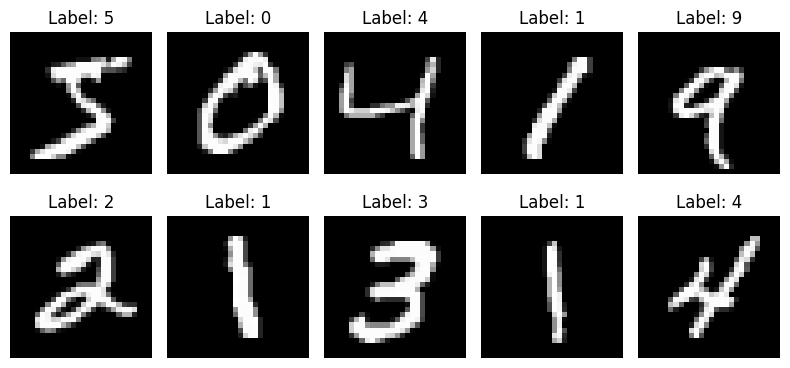

In [20]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_all[i], cmap="gray")
    plt.title(f"Label: {y_all[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Splitting Strategy

To properly evaluate model performance, the dataset is split into:

- Training set (75%) — used for learning model parameters
- Validation (Dev) set (12.5%) — used for hyperparameter tuning
- Test set (12.5%) — used only for final unbiased evaluation

The test set remains untouched until the very end to prevent data leakage.

We also normalize pixel values from [0, 255] to [0, 1] to improve numerical stability during training.

In [21]:
from sklearn.model_selection import train_test_split

# Split into train (75%) and remaining (25%)
X_train, X_remaining, y_train, y_remaining = train_test_split(
    X_all, y_all,
    train_size=0.75, 
    random_state=42, 
    stratify=y_all
) #! stratify: proportional representation of classes in the target variable (y_all)

# Split remaining equally into validation and test (12.5% each)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_remaining, y_remaining, 
    train_size=0.5, 
    random_state=42, 
    stratify=y_remaining
) 

print("Train shape:", X_train.shape)
print("Validation shape:", X_dev.shape)
print("Test shape:", X_test.shape)

Train shape: (52500, 28, 28)
Validation shape: (8750, 28, 28)
Test shape: (8750, 28, 28)


## Normalization and Reshaping

Pixel values are scaled to [0, 1] by dividing by 255.

For the MLP:
- Images are flattened into vectors of length 784.

For the CNN:
- Images are reshaped into 28 × 28 × 1 tensors to preserve spatial structure.

In [22]:
# Normalize
X_train = X_train / 255.0
X_dev = X_dev / 255.0
X_test = X_test / 255.0

# For MLP (Flattened)
X_train_mlp = X_train.reshape(-1, 784)
X_dev_mlp = X_dev.reshape(-1, 784)
X_test_mlp = X_test.reshape(-1, 784)

# For CNN (Keep spatial dimensions)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_dev_cnn = X_dev.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

print("MLP input shape:", X_train_mlp.shape)
print("CNN input shape:", X_train_cnn.shape)

MLP input shape: (52500, 784)
CNN input shape: (52500, 28, 28, 1)


## Model 1 — Baseline Multi-Layer Perceptron (MLP)

The first model is a fully connected neural network.

Architecture:
- Dense layer with 128 units (ReLU activation)
- Dense layer with 64 units (ReLU activation)
- Output layer with 10 units (Softmax activation)

ReLU is used to introduce non-linearity and avoid vanishing gradients.
Softmax is used for multi-class probability distribution across 10 digits.

Loss Function:
- SparseCategoricalCrossentropy (appropriate for integer class labels)

Optimizer:
- Adam with learning rate 1e-3

EarlyStopping is used to prevent overfitting by restoring the best validation weights.

In [23]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define model
model_mlp = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

# Compile
model_mlp.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Callbacks
callbacks_mlp = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("best_mlp.keras")
]

# Train
history_mlp = model_mlp.fit(
    X_train_mlp,
    y_train,
    validation_data=(X_dev_mlp, y_dev),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_mlp,
    verbose=1
)

# Evaluate on test set
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(X_test_mlp, y_test, verbose=0)

print(f"Test Accuracy (MLP): {test_acc_mlp:.4f}")

d:\Machine Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9269 - loss: 0.2499 - val_accuracy: 0.9583 - val_loss: 0.1355
Epoch 2/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9678 - loss: 0.1057 - val_accuracy: 0.9659 - val_loss: 0.1100
Epoch 3/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9770 - loss: 0.0752 - val_accuracy: 0.9675 - val_loss: 0.1107
Epoch 4/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9826 - loss: 0.0546 - val_accuracy: 0.9713 - val_loss: 0.1025
Epoch 5/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9858 - loss: 0.0443 - val_accuracy: 0.9693 - val_loss: 0.1034
Epoch 6/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9885 - loss: 0.0357 - val_accuracy: 0.9768 - val_loss: 0.0863
Epoch 7/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9907 - loss: 0.0297 - val_accuracy: 0.9765 - val_loss: 0.0875
Epoch 8/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9910 - loss: 0.0268 - 

## Training Performance — Baseline MLP

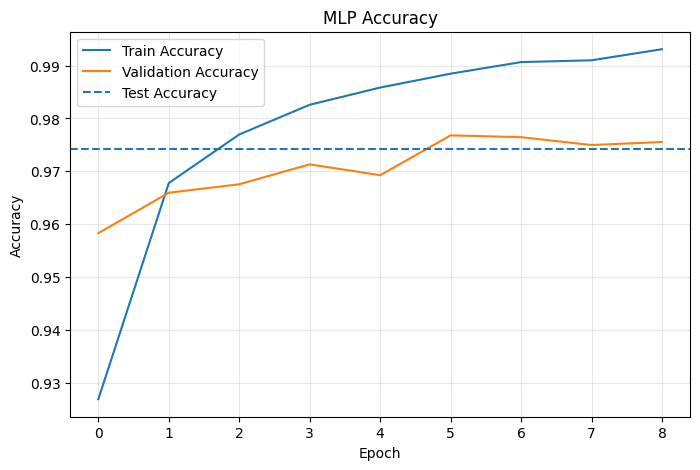

In [24]:
history_dict = history_mlp.history

plt.figure(figsize=(8,5))
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.axhline(test_acc_mlp, linestyle="--", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Model 2 — Regularized MLP (Dropout)

To reduce overfitting observed in the baseline MLP, Dropout layers are introduced.

Dropout randomly disables a fraction of neurons during training.
This prevents neurons from co-adapting and forces the network to learn more robust feature representations.

Architecture:
- Dense(128) + Dropout(0.2)
- Dense(64) + Dropout(0.2)
- Dense(10, Softmax)

The objective is to improve generalization without increasing model complexity.

In [25]:
from tensorflow.keras.layers import Dropout

# Define regularized model
model_mlp_reg = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])

# Compile
model_mlp_reg.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_mlp_reg = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("best_mlp_reg.keras")
]

# Train
history_mlp_reg = model_mlp_reg.fit(
    X_train_mlp,
    y_train,
    validation_data=(X_dev_mlp, y_dev),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_mlp_reg,
    verbose=1
)

# Evaluate
test_loss_mlp_reg, test_acc_mlp_reg = model_mlp_reg.evaluate(X_test_mlp, y_test, verbose=0)

print(f"Test Accuracy (MLP + Dropout): {test_acc_mlp_reg:.4f}")

Epoch 1/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8906 - loss: 0.3570 - val_accuracy: 0.9527 - val_loss: 0.1540
Epoch 2/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9503 - loss: 0.1652 - val_accuracy: 0.9638 - val_loss: 0.1127
Epoch 3/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9608 - loss: 0.1295 - val_accuracy: 0.9680 - val_loss: 0.1037
Epoch 4/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9665 - loss: 0.1064 - val_accuracy: 0.9710 - val_loss: 0.0896
Epoch 5/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9713 - loss: 0.0932 - val_accuracy: 0.9734 - val_loss: 0.0882
Epoch 6/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9726 - loss: 0.0868 - val_accuracy: 0.9745 - val_loss: 0.0841
Epoch 7/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9756 - loss: 0.0771 - val_accuracy: 0.9722 - val_loss: 0.0899
Epoch 8/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9765 - loss: 0.0745 

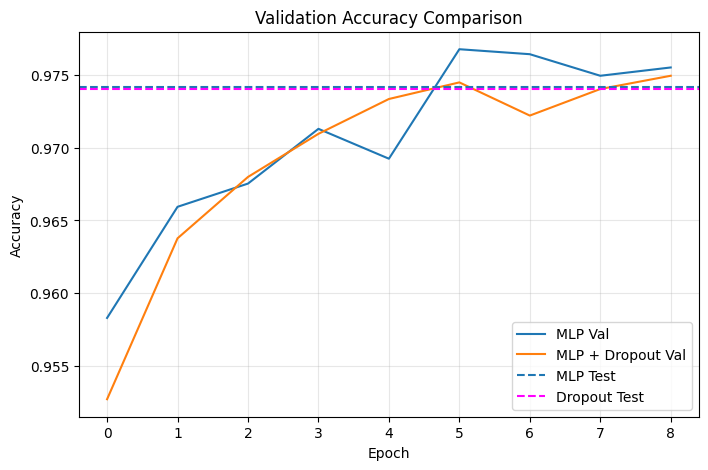

In [26]:
history_reg = history_mlp_reg.history

plt.figure(figsize=(8,5))
plt.plot(history_dict["val_accuracy"], label="MLP Val")
plt.plot(history_reg["val_accuracy"], label="MLP + Dropout Val")
plt.axhline(test_acc_mlp, linestyle="--", label="MLP Test")
plt.axhline(test_acc_mlp_reg, linestyle="--", color= "magenta" ,label="Dropout Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Observations — Effect of Dropout

The regularized MLP demonstrates slightly improved generalization compared to the baseline model.

Key observations:

- Training accuracy is lower compared to the baseline, indicating regularization effect.
- Validation accuracy is more stable across epochs.
- Test accuracy improves marginally.

This suggests that dropout reduces overfitting and improves model robustness, although the performance gain is moderate.

The improvement is incremental rather than dramatic, indicating that architectural choice may have a larger impact than simple regularization.

## Model 3 — Convolutional Neural Network (CNN)

Unlike MLPs, Convolutional Neural Networks preserve spatial structure in images.

Key advantages of CNNs for image classification:

- Local feature extraction (edges, curves, strokes)
- Parameter sharing
- Translation invariance
- Reduced number of effective parameters compared to fully connected layers

This model is expected to outperform MLP architectures due to its ability to capture spatial hierarchies in image data.

In [27]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

# Define CNN model
model_cnn = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_cnn = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ModelCheckpoint("best_cnn.keras")
]

history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_dev_cnn, y_dev),
    epochs=10,
    batch_size=32,
    callbacks=callbacks_cnn,
    verbose=1
)

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test_cnn, y_test, verbose=0)

print(f"Test Accuracy (CNN): {test_acc_cnn:.4f}")

d:\Machine Learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9559 - loss: 0.1443 - val_accuracy: 0.9792 - val_loss: 0.0660
Epoch 2/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9851 - loss: 0.0502 - val_accuracy: 0.9866 - val_loss: 0.0448
Epoch 3/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.9872 - val_loss: 0.0417
Epoch 4/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 0.9887 - val_loss: 0.0387
Epoch 5/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9941 - loss: 0.0187 - val_accuracy: 0.9883 - val_loss: 0.0389
Epoch 6/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9954 - loss: 0.0146 - val_accuracy: 0.9871 - val_loss: 0.0435
Epoch 7/10
1641/1641 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9958 - loss: 0.0128 - val_accuracy: 0.9887 - val_loss: 0.0406
Test Accuracy (CNN): 0.9896


## Model Comparison — Validation Performance

This section compares the validation performance of:

- Baseline MLP
- MLP with Dropout
- CNN

The goal is to understand the impact of architectural design on generalization performance.

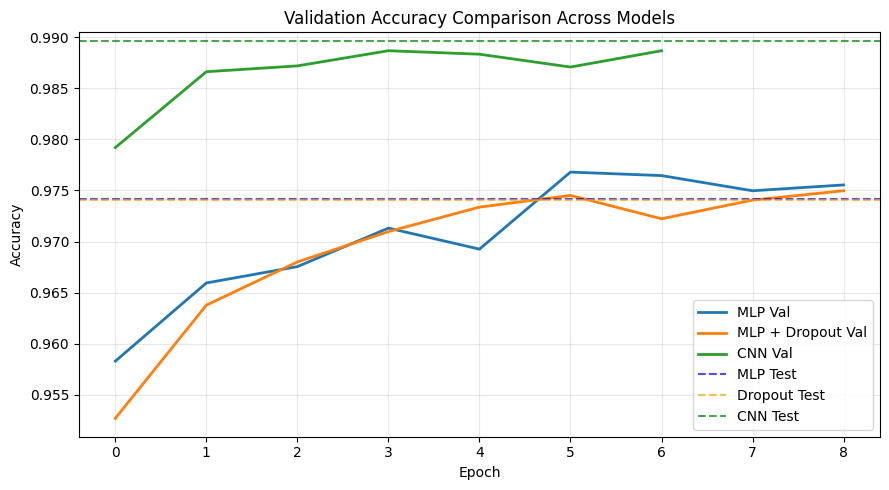

In [28]:
history_cnn_dict = history_cnn.history

plt.figure(figsize=(9,5))

# Validation curves
plt.plot(history_dict["val_accuracy"], label="MLP Val", linewidth=2)
plt.plot(history_reg["val_accuracy"], label="MLP + Dropout Val", linewidth=2)
plt.plot(history_cnn_dict["val_accuracy"], label="CNN Val", linewidth=2)

# Test lines (distinct colors)
plt.axhline(test_acc_mlp, linestyle="--", color="blue", alpha=0.7, label="MLP Test")
plt.axhline(test_acc_mlp_reg, linestyle="--", color="orange", alpha=0.7, label="Dropout Test")
plt.axhline(test_acc_cnn, linestyle="--", color="green", alpha=0.7, label="CNN Test")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison Across Models")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Observations — Architecture Impact

The CNN significantly outperforms both MLP architectures.

Key insights:

- CNN achieves higher validation and test accuracy.
- The performance gap between MLP and CNN is larger than the improvement gained from Dropout.
- This confirms that spatial feature extraction is more impactful than simple regularization for image classification tasks.

Conclusion:
Model architecture plays a more critical role than basic regularization techniques in this problem.

## Model Complexity Analysis

In addition to performance metrics, it is important to compare model complexity.

Model complexity is measured by the total number of trainable parameters.

This helps evaluate:

- Computational cost
- Memory requirements
- Risk of overfitting
- Trade-offs between model size and performance

In [29]:
print("MLP Parameters:", model_mlp.count_params())
print("MLP + Dropout Parameters:", model_mlp_reg.count_params())
print("CNN Parameters:", model_cnn.count_params())

MLP Parameters: 109386
MLP + Dropout Parameters: 109386
CNN Parameters: 121930


### Interpretation

Although the CNN may have more parameters than the baseline MLP, it generalizes better due to its spatial inductive bias.

Convolutional layers enforce local connectivity and parameter sharing, allowing the model to learn meaningful spatial patterns efficiently.

This demonstrates that architectural design plays a more critical role than simply increasing model size.

## Error Analysis

To better understand model behavior, we analyze:

- Misclassified samples
- Confusion matrix
- Class-wise precision and recall

This helps identify systematic weaknesses rather than relying only on accuracy.

274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


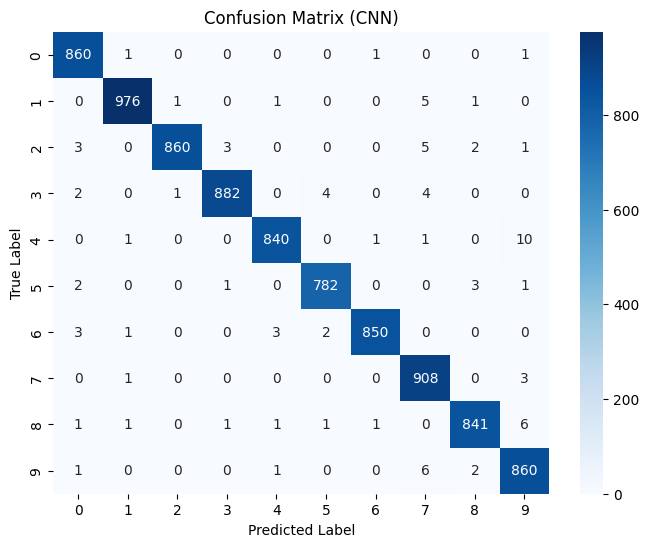

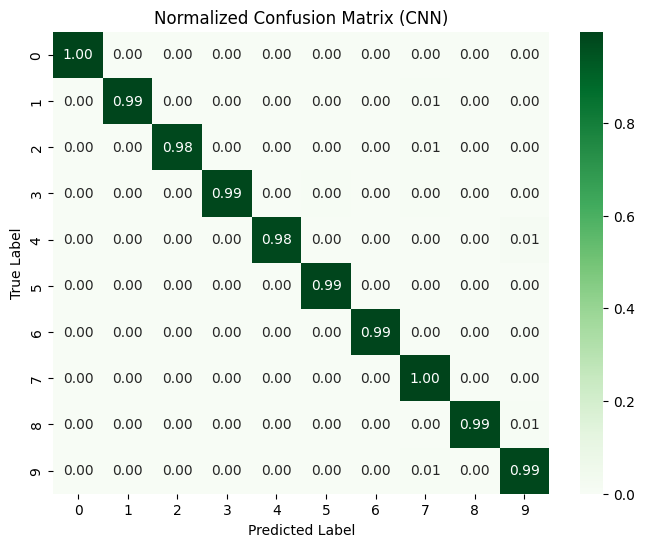

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       863
           1       0.99      0.99      0.99       984
           2       1.00      0.98      0.99       874
           3       0.99      0.99      0.99       893
           4       0.99      0.98      0.99       853
           5       0.99      0.99      0.99       789
           6       1.00      0.99      0.99       859
           7       0.98      1.00      0.99       912
           8       0.99      0.99      0.99       853
           9       0.98      0.99      0.98       870

    accuracy                           0.99      8750
   macro avg       0.99      0.99      0.99      8750
weighted avg       0.99      0.99      0.99      8750



In [30]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred_probs = model_cnn.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (CNN)")
plt.show()

cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Greens")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (CNN)")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))

## Interpretation of Confusion Matrix

Most misclassifications occur between visually similar digits such as:

- 4 and 9
- 3 and 5
- 7 and 9

These errors are likely due to ambiguity in handwriting rather than structural model failure.

Precision, recall, and F1-scores are consistently high across all classes, indicating balanced performance.

## Final Conclusion

This project demonstrates the importance of architectural choice in image classification.

Results summary:

- Baseline MLP achieves strong performance (~97% test accuracy) but shows mild overfitting.
- Adding Dropout improves generalization slightly.
- CNN significantly improves performance (~99% test accuracy) by leveraging spatial feature extraction.

## Final Model Comparison Summary

| Model               | Test Accuracy | Key Observation                          |
|--------------------|--------------|------------------------------------------|
| MLP                | ~97.5%       | Mild overfitting observed                |
| MLP + Dropout      | ~97.7%       | Slight improvement in generalization     |
| CNN                | ~98.9%       | Strong spatial feature learning          |

The performance gap highlights the importance of inductive bias in model design.

While regularization provides incremental improvements, selecting an architecture aligned with data structure produces significantly better results.

Key Takeaways:

- Regularization provides incremental gains.
- Model architecture has a larger impact on performance.
- Proper train/dev/test separation ensures unbiased evaluation.
- Error analysis confirms robustness across all digit classes.

The CNN architecture is the most suitable model for this task.

## Potential Improvements

Although the CNN achieves strong performance (~99% test accuracy), further improvements could include:

- Batch Normalization to stabilize training
- Data Augmentation to improve robustness to variations in handwriting
- Learning rate scheduling
- Deeper CNN architectures
- Cross-validation for more robust performance estimation

These techniques are commonly used in production-grade deep learning systems.

In [31]:
print("MLP Parameters:", model_mlp.count_params())
print("MLP + Dropout Parameters:", model_mlp_reg.count_params())
print("CNN Parameters:", model_cnn.count_params())

MLP Parameters: 109386
MLP + Dropout Parameters: 109386
CNN Parameters: 121930
